# Part 3a: Reuse Factor

In Part 1c we used the default hls4ml configuration, which maps the entire neural network onto the FPGA with maximum parallelism, so that all multiply-accumulate operation run in parallel. This gives the lowest possible latency, but consumes a lot of resources.

The **reuse factor (RF)** is a variable in hls4ml for tuning the trade-off between resource consumption and latency. In this notebook we explore how changing it affects the synthesized design.

Run either `1_getting_started/1a_train_keras.ipynb` or `1_getting_started/1b_train_pytorch.ipynb` first, then set `MODEL_TYPE` below.

In [1]:
MODEL_TYPE = 'keras'  # set to 'pytorch' if you used the PyTorch notebook in Part 1

In [2]:
import os

os.environ['KERAS_BACKEND'] = 'tensorflow'

import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('..')
import plotting
import hls4ml
from sklearn.metrics import accuracy_score

%matplotlib inline

os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']

# Load the data
X_test = np.ascontiguousarray(np.load('../data/jet-tagging/X_test.npy'), dtype=np.float32)
y_test = np.load('../data/jet-tagging/y_test.npy')
classes = np.load('../data/jet-tagging/classes.npy', allow_pickle=True)

## Load the trained model

Load the model saved by Part 1a or 1b.

In [3]:
if MODEL_TYPE == 'keras':
    import tensorflow as tf

    trained_model = tf.keras.models.load_model('../models/keras_model_part1.h5')
    y_ref = trained_model.predict(X_test)

elif MODEL_TYPE == 'pytorch':
    import torch
    import torch.nn as nn

    class JetTagger(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(16, 64)
            self.fc2 = nn.Linear(64, 32)
            self.fc3 = nn.Linear(32, 32)
            self.output = nn.Linear(32, 5)

        def forward(self, x):
            x = torch.relu(self.fc1(x))
            x = torch.relu(self.fc2(x))
            x = torch.relu(self.fc3(x))
            return torch.softmax(self.output(x), dim=1)

    trained_model = JetTagger()
    trained_model.load_state_dict(torch.load('../models/pytorch_weights_part1.pt'))
    trained_model.eval()
    with torch.no_grad():
        y_ref = trained_model(torch.FloatTensor(X_test)).numpy()

print('Accuracy: {:.4f}'.format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_ref, axis=1))))

I0000 00:00:1784147621.244022   34179 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784147621.301814   34179 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784147623.975924   34179 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1784147630.449232   34179 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


5188/5188 ━━━━━━━━━━━━━━━━━━━━ 5s 800us/step
Accuracy: 0.7631


## What is the ReuseFactor?

In the default (`ReuseFactor = 1`) configuration, hls4ml instantiates one multiplier for every weight in the network. All multiplications for a given layer happen in a single clock cycle, giving the minimum possible latency — but using the most multipliers.

Setting `ReuseFactor = N` tells hls4ml to time-multiplex the same multiplier hardware across `N` weight-input pairs. This means the layer takes `N` clock cycles to compute instead of one, but uses roughly `1/N` as many multipliers.

![Reuse factor diagram](../images/part3a_reuse_factor.png)

The reuse factor must evenly divide the number of weights in each layer. For example, the first layer has `16 × 64 = 1024` weights, so valid reuse factors include 1, 2, 4, 8, 16, 32, 64, etc.

Changing the reuse factor does **not** change the model accuracy — the same arithmetic is performed, just spread over more clock cycles. We will verify this below.

## Set ReuseFactor = 4

Let's create a new configuration with `ReuseFactor = 4` set globally. Note that we use `granularity='model'` here, which applies one set of defaults to all layers — equivalent to the config from Part 1c.

In [4]:
if MODEL_TYPE == 'keras':
    config = hls4ml.utils.config_from_keras_model(trained_model, granularity='model', backend='Vitis')
elif MODEL_TYPE == 'pytorch':
    config = hls4ml.utils.config_from_pytorch_model(trained_model, input_shape=(16,), granularity='model', backend='Vitis')

config['Model']['ReuseFactor'] = 4
print('-----------------------------------')
plotting.print_dict(config)
print('-----------------------------------')

-----------------------------------
Model
  Precision
    default:         fixed<16,6>
  ReuseFactor:       4
  Strategy:          Latency
  BramFactor:        1000000000
  TraceOutput:       False
-----------------------------------


In [5]:
if MODEL_TYPE == 'keras':
    hls_model = hls4ml.converters.convert_from_keras_model(
        trained_model,
        hls_config=config,
        backend='Vitis',
        output_dir='../hls4ml_prjs/hls4ml_prj_reuse_part3a',
        part='xcu200-fsgd2104-2-e',
    )
elif MODEL_TYPE == 'pytorch':
    hls_model = hls4ml.converters.convert_from_pytorch_model(
        trained_model,
        hls_config=config,
        backend='Vitis',
        output_dir='../hls4ml_prjs/hls4ml_prj_reuse_part3a',
        part='xcu200-fsgd2104-2-e',
    )

hls_model.compile()
y_hls = hls_model.predict(X_test)

## Compare

Changing the reuse factor only affects resource usage and latency — not accuracy. Let's verify that the accuracy and ROC curves are identical.

keras Accuracy: 0.7631
hls4ml Accuracy: 0.7619


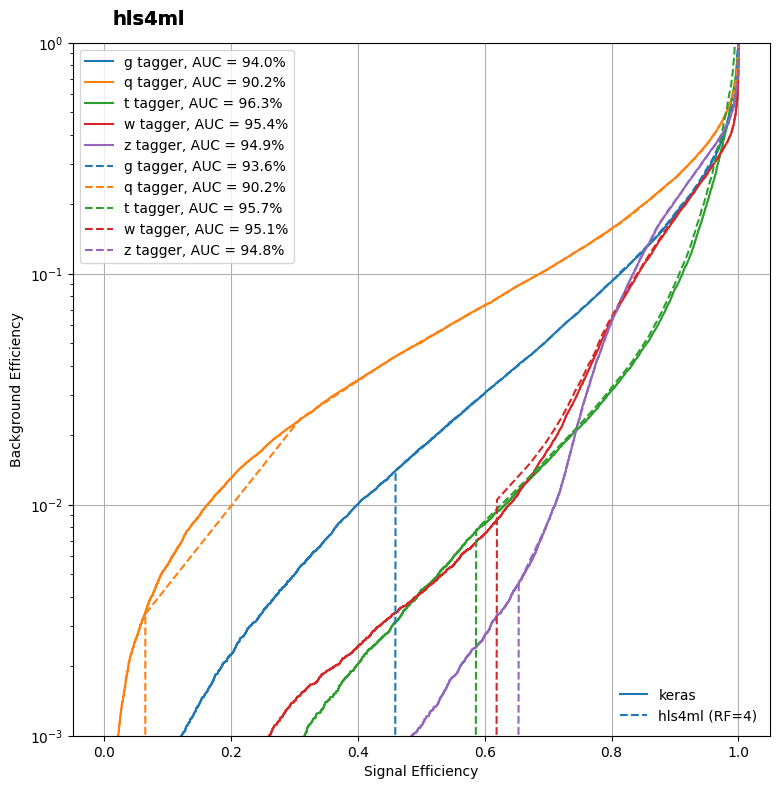

In [6]:
print('{} Accuracy: {:.4f}'.format(MODEL_TYPE, accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_ref, axis=1))))
print('hls4ml Accuracy: {:.4f}'.format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))))

fig, ax = plt.subplots(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_ref, list(classes))
plt.gca().set_prop_cycle(None)
_ = plotting.makeRoc(y_test, y_hls, list(classes), linestyle='--')

from matplotlib.lines import Line2D
from matplotlib.legend import Legend

lines = [Line2D([0], [0], ls='-'), Line2D([0], [0], ls='--')]
leg = Legend(ax, lines, labels=[MODEL_TYPE, 'hls4ml (RF=4)'], loc='lower right', frameon=False)
ax.add_artist(leg)

## Synthesize

Now let's synthesize with `ReuseFactor = 4` and compare the resource report against the Part 1c baseline (`ReuseFactor = 1`) to see the effect.

**This can take several minutes.**

In [7]:
hls_model.build(csim=False)


****** vitis-run v2024.2 (64-bit)
  **** SW Build 5239630 on 2024-11-10-11:19:46
  **** Start of session at: Wed Jul 15 22:34:28 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2024.2 5238294
Sourcing Tcl script '/home/enlupi/Work/repo/hls4ml-tutorial/hls4ml_prjs/hls4ml_prj_reuse_part3a/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project myproject_prj 
INFO: [HLS 200-10] Creating and opening project '/home/enlupi/Work/repo/hls4ml-tutorial/hls4ml_prjs/hls4ml_prj_reuse_part3a/myproject_prj'.
INFO: [HLS 200-1510] Running: set_top myproject 
INFO: [HLS 200-1510] Running: add_files firmware/myproject.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding design file 'firmware/myproject.cpp' to the project
INFO: [HLS 200-1510] Running: add_files -tb myproject_test.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding test bench file 'myproject_test.cpp' to the project
INFO: [HLS 20

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '3.523',
  'BestLatency': '26',
  'WorstLatency': '26',
  'IntervalMin': '4',
  'IntervalMax': '4',
  'BRAM_18K': '5',
  'DSP': '1069',
  'FF': '38809',
  'LUT': '151228',
  'URAM': '0',
  'AvailableBRAM_18K': '4320',
  'AvailableDSP': '6840',
  'AvailableFF': '2364480',
  'AvailableLUT': '1182240',
  'AvailableURAM': '960'}}

## Compare reports

Print both reports and compare the DSP and LUT usage. With `ReuseFactor = 4`, you should see roughly a quarter as many DSPs as in the Part 1c baseline, at the cost of approximately four times the latency (in clock cycles).

In [8]:
print('ReuseFactor = 4:')
hls4ml.report.read_vivado_report('../hls4ml_prjs/hls4ml_prj_reuse_part3a')

ReuseFactor = 4:
Found 1 solution(s) in ../hls4ml_prjs/hls4ml_prj_reuse_part3a/myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'myproject'
* Date:           Wed Jul 15 22:37:52 2026

* Version:        2024.2 (Build 5238294 on Nov  8 2024)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: virtexuplus
* Target device:  xcu200-fsgd2104-2-e


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.523 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+----------+----------+-----+-----+---------+
    |  Latency (cycles) |  Latency (absolute) |  Interval | Pipeline|
    |   min   |   max   |    min   |    max   | min | max |   Type

In [9]:
print('ReuseFactor = 1 (Part 1c baseline):')
hls4ml.report.read_vivado_report('../hls4ml_prjs/hls4ml_prj_base_part1')

ReuseFactor = 1 (Part 1c baseline):
Found 1 solution(s) in ../hls4ml_prjs/hls4ml_prj_base_part1/myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'myproject'
* Date:           Wed Jul 15 22:07:23 2026

* Version:        2024.2 (Build 5238294 on Nov  8 2024)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: virtexuplus
* Target device:  xcu200-fsgd2104-2-e


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.490 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+-----------+-----------+-----+-----+---------+
    |  Latency (cycles) |   Latency (absolute)  |  Interval | Pipeline|
    |   min   |   max   |    min    |    max 

## Further reading

For more details, see: Schulte, Ramhorst, Sun et al., "hls4ml: A Flexible, Open-Source Platform for Deep Learning Acceleration on Reconfigurable Hardware", ACM Trans. Reconfigurable Technol. Syst. (2026), [doi:10.1145/3801979](https://dl.acm.org/doi/abs/10.1145/3801979)